# Kalman Filter and Dynamic Bayesian Networks

Temporal probabilistic models from [`probability.py`](probability.py): the Kalman filter (Section 15.4) and dynamic Bayesian networks (Section 15.5).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from probability import KalmanFilter, kalman_filter, DynamicBayesNet, T, F

## 15.4 Kalman filter: tracking a 1-D random walk
A hidden value drifts as a random walk and is measured with noise; the Kalman filter recovers a smooth estimate from the noisy measurements.

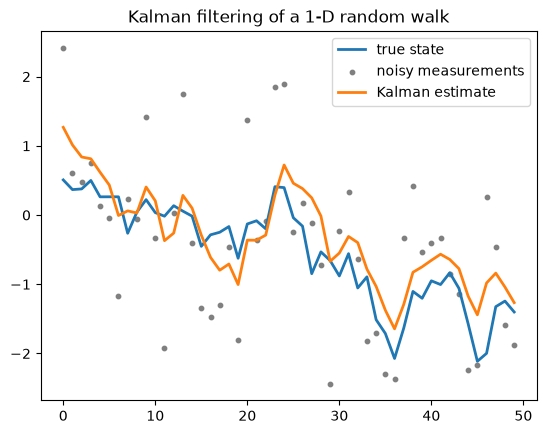

In [2]:
np.random.seed(7)
truth, x = [], 0.0
for _ in range(50):
    x += np.random.normal(0, 0.3)
    truth.append(x)
measurements = [v + np.random.normal(0, 1.0) for v in truth]

kf = KalmanFilter(transition_model=[[1]], sensor_model=[[1]],
                  transition_noise=[[0.1]], sensor_noise=[[1]])
estimates = kalman_filter(kf, mean0=[0], cov0=[[1]], observations=measurements)
filtered = [m[0] for m, _ in estimates]

plt.plot(truth, label='true state', linewidth=2)
plt.scatter(range(50), measurements, s=10, c='gray', label='noisy measurements')
plt.plot(filtered, label='Kalman estimate', linewidth=2)
plt.legend(); plt.title('Kalman filtering of a 1-D random walk'); plt.show()

## 15.5 Dynamic Bayesian network: the umbrella world
The DBN is unrolled into an ordinary Bayes net and queried by exact inference. Filtering reproduces the canonical umbrella values 0.818 and 0.883.

In [3]:
dbn = DynamicBayesNet(prior=[('Rain', '', 0.5)],
                      transition=[('Rain', 'Rain_prev', {T: 0.7, F: 0.3})],
                      sensors=[('Umbrella', 'Rain', {T: 0.9, F: 0.2})])
print('unrolled (2 steps):', dbn.unroll(2).variables)
print('P(Rain_1 | umbrella)        =', round(dbn.filter([{'Umbrella': True}], 'Rain')[True], 4))
print('P(Rain_2 | umbrella, umbrella) =',
      round(dbn.filter([{'Umbrella': True}, {'Umbrella': True}], 'Rain')[True], 4))

unrolled (2 steps): ['Rain_0', 'Rain_1', 'Umbrella_1', 'Rain_2', 'Umbrella_2']
P(Rain_1 | umbrella)        = 0.8182
P(Rain_2 | umbrella, umbrella) = 0.8834
